# Workstream B — Spread Interbancaire
## Analyse, Modélisation AR, GARCH, Markov




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

FILE = r"C:\Users\eyasf\OneDrive\Desktop\TSA_project\Data\FX Data.xlsx"
xls = pd.ExcelFile(FILE)

# DATA
Bct_fixing_USD = pd.read_excel(xls, "BCT Fixing USD")
Interbancaire  = pd.read_excel(xls, "InterBancaire")

IB = Interbancaire[['Date','USD']].copy()
IB.columns = ['Date','USD_IB']
IB['Date'] = pd.to_datetime(IB['Date'])
IB = IB.dropna(subset=['USD_IB'])
IB = IB[IB['USD_IB'] > 0]

Fix = Bct_fixing_USD[['Exchange Date','Mid Price']].copy()
Fix.columns = ['Date','Fixing_USD']
Fix['Date'] = pd.to_datetime(Fix['Date'])
Fix = Fix.dropna()

IB = IB[IB['Date'] >= Fix['Date'].min()].reset_index(drop=True)

# Merge 
df = pd.merge(IB, Fix, on='Date', how='inner')
df['Fixing_lag'] = df['Fixing_USD'].shift(1)
df['Spread_lag'] = df['USD_IB'] - df['Fixing_lag']  
df = df.dropna().reset_index(drop=True)

print(f"Dataset B : {len(df)} obs  ({df['Date'].min().date()} → {df['Date'].max().date()})")
print(f"\nStats du Spread_lag :")
print(df['Spread_lag'].describe().round(6))
print(f"Skewness : {df['Spread_lag'].skew():.4f}")
print(f"Kurtosis : {df['Spread_lag'].kurt():.4f}")


Dataset B : 1460 obs  (2020-04-13 → 2026-01-26)

Stats du Spread_lag :
count    1460.000000
mean        0.008454
std         0.022065
min        -0.057250
25%        -0.004500
50%         0.002400
75%         0.018425
max         0.113000
Name: Spread_lag, dtype: float64
Skewness : 1.2397
Kurtosis : 2.6578


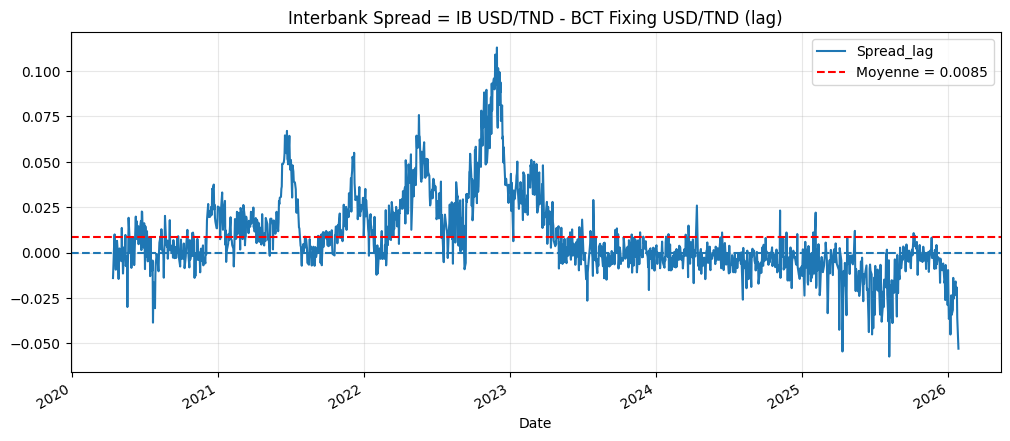

In [ ]:
#  Visualisation spread
df.set_index('Date')['Spread_lag'].plot(figsize=(12,5))
plt.title("Interbank Spread = IB USD/TND - BCT Fixing USD/TND (lag)")
plt.axhline(0, linestyle='--')
plt.axhline(df['Spread_lag'].mean(), linestyle='--', color='red',
            label=f"Mean = {df['Spread_lag'].mean():.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('WS_B_spread.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# STATIONARITY TEST
adf_result = adfuller(df['Spread_lag'])
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Critical Values: {adf_result[4]}")

stat, p_value, lags, crit = kpss(df['Spread_lag'], regression='c')
print(f"\nKPSS stat    : {stat:.4f}")
print(f"KPSS p-value : {p_value:.4f}")
print("\n→ Contradictory results : ADF suggests stationarity, KPSS suggests non-stationarity.")


ADF Statistic : -2.7259
p-value       : 0.0697
Critical Values: {'1%': np.float64(-3.4348772553489617), '5%': np.float64(-2.8635394783531085), '10%': np.float64(-2.5678345067434516)}

KPSS stat    : 1.7818
KPSS p-value : 0.0100

→ Tests contradictoires — on travaille en niveaux (mean-reversion économique)


In [ ]:
#AR(1) to AR(4)
from statsmodels.stats.diagnostic import acorr_ljungbox

print("Selection of the order AR :")
print(f"{'Order':<8} {'R²':<8} {'AIC':<12} {'DW':<8} {'LB(10) p':<12} {'Verdict'}")
print("-"*60)

for p in range(1, 7):
    Xar = pd.DataFrame({'const': 1.0}, index=df.index)
    for lag in range(1, p+1):
        Xar[f'lag{lag}'] = df['Spread_lag'].shift(lag)
    Xar = Xar.dropna()
    yar = df['Spread_lag'].loc[Xar.index]
    mar = sm.OLS(yar, Xar).fit()
    dw  = durbin_watson(mar.resid)
    lb_p = acorr_ljungbox(mar.resid, lags=[10], return_df=True)['lb_pvalue'].values[0]
    verdict = '✓ white noise residuals ← SELECTED' if lb_p > 0.05 else '✗'
    print(f"AR({p})   {mar.rsquared:.3f}   {mar.aic:.1f}     {dw:.3f}    {lb_p:.4f}      {verdict}")


Sélection de l'ordre AR :
Ordre    R²       AIC          DW       LB(10) p     Verdict
------------------------------------------------------------
AR(1)   0.760   -9065.2     2.779    0.0000      ✗
AR(2)   0.808   -9384.5     2.211    0.0000      ✗
AR(3)   0.819   -9463.3     2.074    0.0000      ✗
AR(4)   0.824   -9495.4     2.028    0.0005      ✗
AR(5)   0.826   -9502.9     2.004    0.0575      ✓ résidus blancs ← RETENU
AR(6)   0.827   -9501.7     2.001    0.3312      ✓ résidus blancs ← RETENU


                            OLS Regression Results                            
Dep. Variable:             Spread_lag   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     3063.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        22:36:50   Log-Likelihood:                 4695.2
No. Observations:                1458   AIC:                            -9384.
Df Residuals:                    1455   BIC:                            -9369.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0005      0.000      1.979      

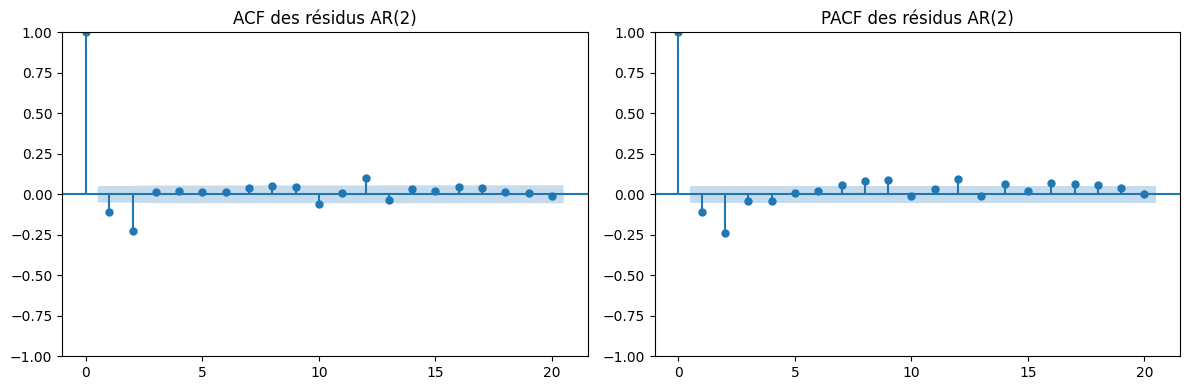

Durbin-Watson AR(2) : 2.2109


In [ ]:
# AR(2) 
df['Spread_lag1'] = df['Spread_lag'].shift(1)
df['Spread_lag2'] = df['Spread_lag'].shift(2)
df_ar2 = df.dropna()

X2 = sm.add_constant(df_ar2[['Spread_lag1','Spread_lag2']])
y2 = df_ar2['Spread_lag']
model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

residuals2 = model2.resid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals2,  lags=20, ax=axes[0], title="ACF of residuals AR(2)")
plot_pacf(residuals2, lags=20, ax=axes[1], title="PACF of residuals AR(2)")
plt.tight_layout()
plt.savefig('WS_B_AR2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

dw2 = durbin_watson(residuals2)
print(f"Durbin-Watson AR(2) : {dw2:.4f}")


GARCH(1,1) résultats :
  α = 0.3055
  β = 0.6765
  α+β = 0.9821  → persistance très élevée
  σ courante = 0.026595 TND


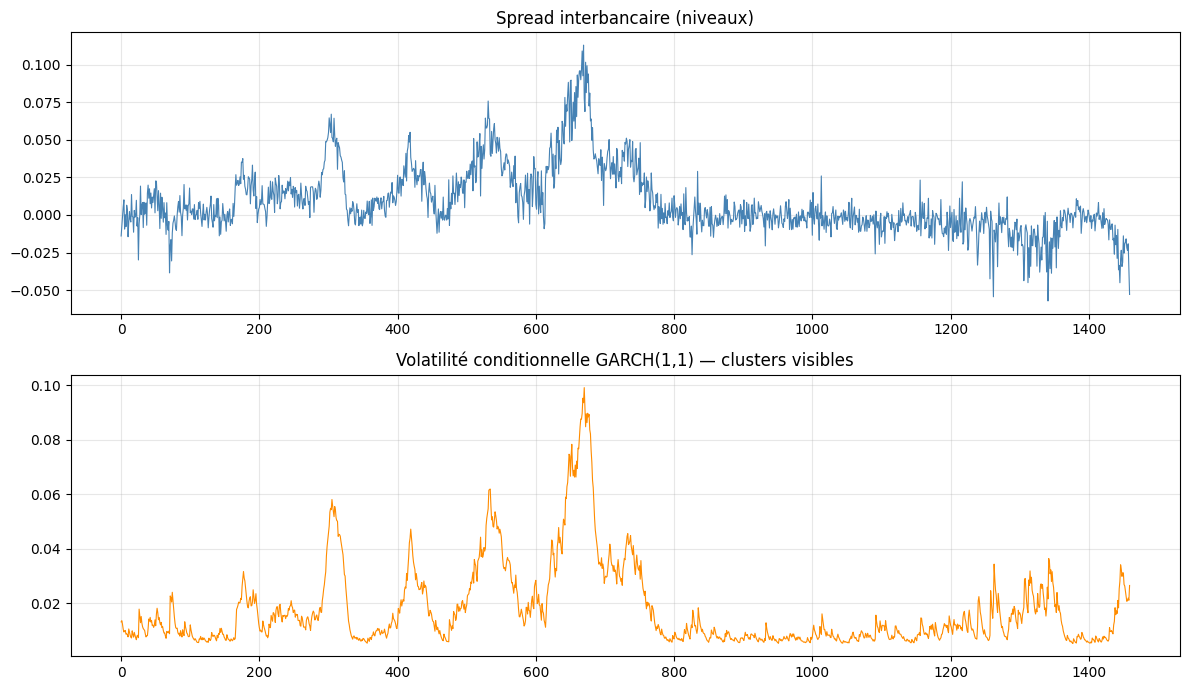

In [ ]:
#  GARCH(1,1)
spread_scaled = df['Spread_lag'] * 100  

garch = arch_model(spread_scaled, vol='Garch', p=1, q=1, mean='Constant', rescale=False)
garch_result = garch.fit(disp='off')

# Volatitility
sigma_series  = garch_result.conditional_volatility / 100
latest_sigma  = sigma_series.iloc[-1]

alpha_g = garch_result.params['alpha[1]']
beta_g  = garch_result.params['beta[1]']

print(f"GARCH(1,1) results :")
print(f"  α = {alpha_g:.4f}")
print(f"  β = {beta_g:.4f}")
print(f"  α+β = {alpha_g+beta_g:.4f}  → persistance {'high' if alpha_g+beta_g>0.95 else 'moderate'}")
print(f"  σ courante = {latest_sigma:.6f} TND")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
df['Spread_lag'].plot(ax=axes[0], lw=0.8, color='steelblue')
axes[0].set_title('Spread interbancaire (levels)')
axes[0].grid(True, alpha=0.3)

pd.Series(sigma_series.values, index=df.index).plot(ax=axes[1], color='darkorange', lw=0.8)
axes[1].set_title('Conditional volatility GARCH(1,1) — visible clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('WS_B_GARCH.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Modèle de Markov (code original conservé) ────────────
spread_vals = df['Spread_lag'].dropna()

markov_model = MarkovRegression(
    spread_vals, k_regimes=2, trend='c', switching_variance=True
)
markov_result = markov_model.fit()
print(markov_result.summary())

probs = markov_result.smoothed_marginal_probabilities
probs.columns = [0, 1]

# Identification des régimes
regime_label = np.where(probs[1] > probs[0], 1, 0)

regime_stats = pd.DataFrame({
    'mean':  [df['Spread_lag'][regime_label==r].mean() for r in [0,1]],
    'std':   [df['Spread_lag'][regime_label==r].std()  for r in [0,1]],
    'count': [(regime_label==r).sum()                  for r in [0,1]]
}, index=['Régime 0','Régime 1'])

print("\nStatistiques par régime :")
print(regime_stats.round(5))

stable_regime = int(regime_stats['std'].idxmin().replace('Régime ',''))
stress_regime = int(regime_stats['std'].idxmax().replace('Régime ',''))
print(f"\nStable : {stable_regime}  |  Stress : {stress_regime}")


                        Markov Switching Model Results                        
Dep. Variable:             Spread_lag   No. Observations:                 1460
Model:               MarkovRegression   Log Likelihood                4197.279
Date:                Mon, 11 May 2026   AIC                          -8382.558
Time:                        22:36:53   BIC                          -8350.840
Sample:                             0   HQIC                         -8370.726
                               - 1460                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0019      0.000     -5.483      0.000      -0.003      -0.001
sigma2       6.32e-05   5.24e-06     12.066      0.0

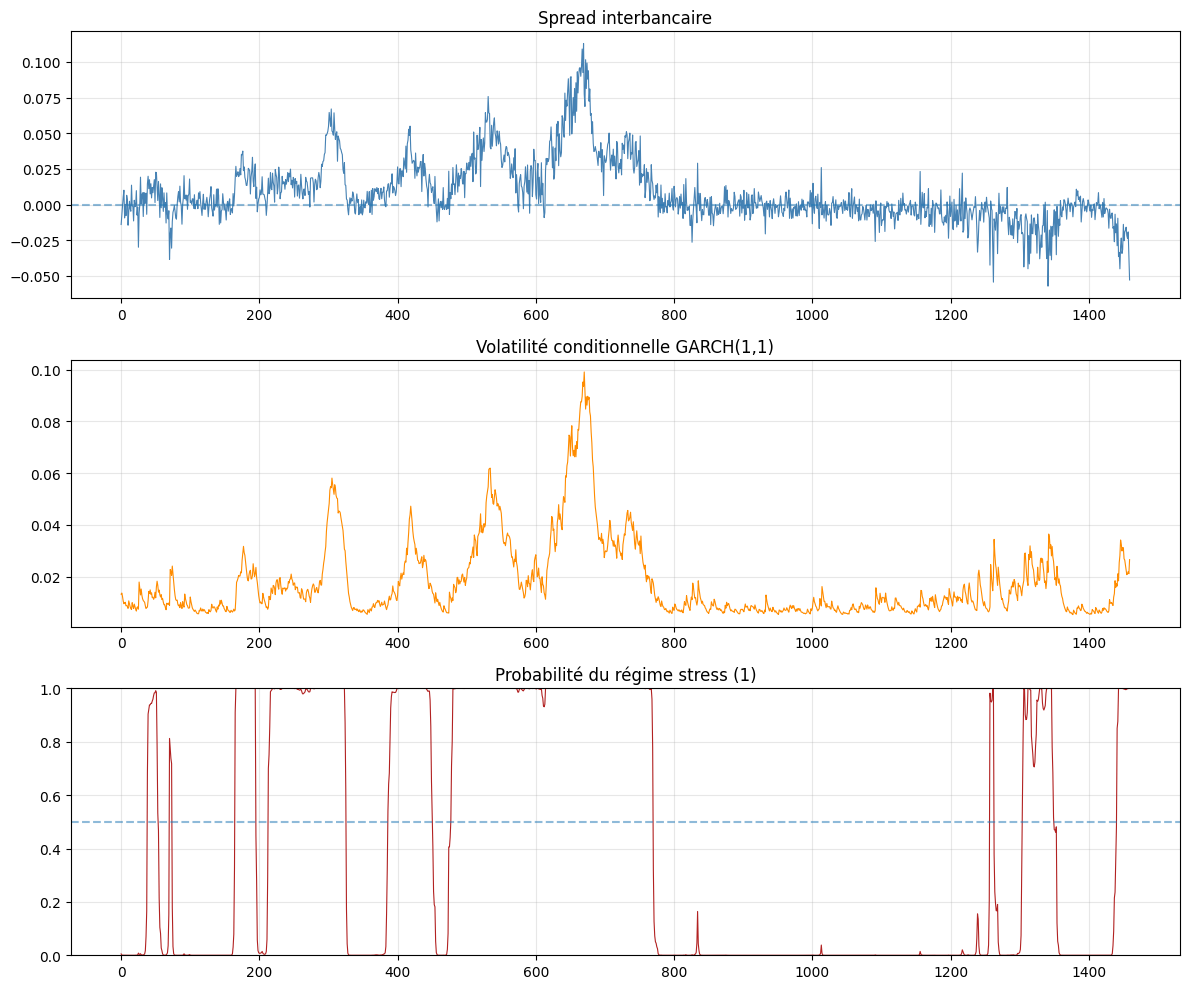


Données Markov sauvegardées pour Workstream C


In [ ]:
# ── Visualisation Markov ──────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

df['Spread_lag'].plot(ax=axes[0], lw=0.8, color='steelblue')
axes[0].axhline(0, linestyle='--', alpha=0.5)
axes[0].set_title('Spread interbank')
axes[0].grid(True, alpha=0.3)

pd.Series(sigma_series.values, index=df.index).plot(ax=axes[1], color='darkorange', lw=0.8)
axes[1].set_title('Conditional volatility GARCH(1,1)')
axes[1].grid(True, alpha=0.3)

probs[stress_regime].plot(ax=axes[2], color='firebrick', lw=0.8)
axes[2].axhline(0.5, linestyle='--', alpha=0.5)
axes[2].set_title(f"Probability of stress regime ({stress_regime})")
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('WS_B_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarder pour Workstream C
import pickle
markov_data = {
    'probs': probs,
    'regime_label': regime_label,
    'stable_regime': stable_regime,
    'stress_regime': stress_regime,
    'latest_sigma': latest_sigma,
    'df': df
}
with open('markov_data.pkl', 'wb') as f:
    pickle.dump(markov_data, f)
print("\nData for Markov model saved to 'markov_data.pkl' for use in Workstream C.")
